In [1]:
# Import all the main libraries needed for cleaning
# These libraries help with handling data, doing calculations, making visuals
# and categorical variables like borough names for analysis

# Import numpy for numerical operations and math functions
import numpy as np

# Import pandas for loading and working with structures data like tables and dataframes
import pandas as pd

# Import matplotlib's pyplot module for creating basic plots and charts
import matplotlib.pyplot as plt

# Import seaborn for making nicer looking statistical visuals
import seaborn as sns

# Import OneHotEncoder to convert categorical borough columns into a numeric format for modeling
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Denote the file paths for the three datasets that will be used throughout this project
# Each file represents a different part of the analysis which is the traffic volume,
# fine particles, and NO2

# File path for the automated traffic volume counts dataset
traffic_file_path = r'data_files\Automated_Traffic_Volume_Counts_20260418.csv'

# File path for the fine particles (PM 2.5) dataset from the NYC EH Data Portal
fine_particles_file_path = r'data_files\NYC EH Data Portal - Fine particles (PM 2.5) (filtered).csv'

# File path for the nitrogen dioxide (NO2) dataset from the NYC EH Data Portal
nitrogen_dioxide_file_path = r'data_files\NYC EH Data Portal - Nitrogen dioxide (NO2) (filtered).csv'

In [3]:
# Read in three datasets as pandas dataframes so that it can be analyzed and cleaned
# Each dataframe will be used separately before being merged

# Load the traffic volume dataset into a dataframe
traffic_df = pd.read_csv(traffic_file_path)

# Load the fine particles dataset into a dataframe
fine_particles_df = pd.read_csv(fine_particles_file_path)

# Load the nitrogen dioxide dataset into a dataframe
nitrogen_dioxide_df = pd.read_csv(nitrogen_dioxide_file_path)

In [4]:
# Make a IQR function to find outliers across all three datasets
# The IQR method flags the values that fall too far below Q1 or above Q3
# based on the spread of the data
# Lets us check for outliers in any column without rewriting the same logic every time

def find_iqr_outliers(df, column):
    # Calculate the first quartile (25th percentile)
    q1 = df[column].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    q3 = df[column].quantile(0.75)

    # Calculate the interquartile range (IQR)
    iqr = q3 - q1

    # Anything below this is a lower outlier
    lower_bound = q1 - (1.5 * iqr)

    # Anything above this is a upper outlier
    upper_bound = q3 + (1.5 * iqr)

    # Filter the dataframe to only return the rows that fall outside the bounds
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Return all of the outliers
    return outliers

In [5]:
# Exploratory data analysis for the traffic dataset
# Take a look at the structure of the data, including the columns, shape, and data types,
# so we know what we are working with before doing any cleaning
 
# Print the column names in the traffic dataset 
print(f'Traffic Columns: {traffic_df.columns}\n')

# Print the number of rows and columsn in the traffic dataset
print(f'Traffic Shape: {traffic_df.shape}\n')

# Print the first few rows of the traffic dataset to see what the data looks like
print(f'Traffic DF Head:\n{traffic_df.head()}\n')

# Print some detailed info about the trafic dataset like column types, null counts, etc
print('Traffic DF Info:')
traffic_df.info()

Traffic Columns: Index(['RequestID', 'Boro', 'Yr', 'M', 'D', 'HH', 'MM', 'Vol', 'SegmentID',
       'WktGeom', 'street', 'fromSt', 'toSt', 'Direction'],
      dtype='str')

Traffic Shape: (1875154, 14)

Traffic DF Head:
   RequestID    Boro    Yr  M  D  HH  MM Vol  SegmentID  \
0      12512  Queens  2013  3  7   4  15   5      55135   
1      12512  Queens  2013  3  7   4  30   8      55135   
2      12512  Queens  2013  3  7   4  45   8      55135   
3      12512  Queens  2013  3  7   5   0   7      55135   
4      12512  Queens  2013  3  7   5  15   9      55135   

                      WktGeom  street     fromSt           toSt Direction  
0  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
1  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
2  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
3  POINT (1035363.4 185093.4)  122 PL  SUTTER AV  ROCKAWAY BLVD        SB  
4  POINT (1035363.4 185093.4)  122 PL  SUTTER

In [6]:
# Loop through each column in the traffic dataset and print the data type and unique values
# Helps spot any unexpected values or formatting issues that need to be fixed

for col in traffic_df.columns:
    # Print the data type of the column
    print(f'Column {col}: {traffic_df[col].dtype}\n')
    # Print the unique values in the column to see if there is anything unusual
    print(f'Traffic DF Unique Values for {col}:{traffic_df[col].unique()}\n')

Column RequestID: int64

Traffic DF Unique Values for RequestID:[12512 27853 28842 ...  9568 21450 21077]

Column Boro: str

Traffic DF Unique Values for Boro:<StringArray>
['Queens', 'Bronx', 'Brooklyn', 'Manhattan', 'Staten Island']
Length: 5, dtype: str

Column Yr: int64

Traffic DF Unique Values for Yr:[2013 2018 2009 2023 2012 2016 2008 2014 2021 2010 2011 2015 2017 2019
 2024 2022 2020 2007 2006 2000 2026 2025]

Column M: int64

Traffic DF Unique Values for M:[ 3  4 11 10  5  9  7  1 12  2  6  8]

Column D: int64

Traffic DF Unique Values for D:[ 7  8 10  9 18  5  3  4 15 16 30 31  1 12 13 24 25 21 22 14 29 19 26 17
 11  2 27 28  6 23 20]

Column HH: int64

Traffic DF Unique Values for HH:[ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23  0  1  2  3]

Column MM: int64

Traffic DF Unique Values for MM:[15 30 45  0 40 50 10 20]

Column Vol: str

Traffic DF Unique Values for Vol:<StringArray>
[    '5',     '8',     '7',     '9',     '4',    '13',    '27',    '17',
    '26

In [7]:
# Drop columsn from the traffic ataset that are not needed for the analysis
# street, formSt, and toSt are not needed for the analysis as the analysis is conducted at the borough level
# SegmentID and WktGeom were kept in case they are useful for future geospatial analysis

# List of the columns to remove from the traffic dataset
traffic_cols_to_remove = ['street', 'fromSt', 'toSt']

# Drop the columns that are not needed and store the results in a new cleaned dataframe
traffic_df_cleaned = traffic_df.drop(columns = traffic_cols_to_remove)

# Check the updated sturcutre of the cleaned traffic dataframe
traffic_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1875154 entries, 0 to 1875153
Data columns (total 11 columns):
 #   Column     Dtype
---  ------     -----
 0   RequestID  int64
 1   Boro       str  
 2   Yr         int64
 3   M          int64
 4   D          int64
 5   HH         int64
 6   MM         int64
 7   Vol        str  
 8   SegmentID  int64
 9   WktGeom    str  
 10  Direction  str  
dtypes: int64(7), str(4)
memory usage: 157.4 MB


In [8]:
# Check for any null values in the traffic dataset and calculate them as a percentage
# Gives a better sense of how much data is missing before deciding how to handle it

# Print the percentage of null values for each column in the cleaned traffic dataframe
print(f'Percentage of Null Values:\n{traffic_df_cleaned.isnull().sum() / len(traffic_df_cleaned) * 100}\n')

Percentage of Null Values:
RequestID    0.0
Boro         0.0
Yr           0.0
M            0.0
D            0.0
HH           0.0
MM           0.0
Vol          0.0
SegmentID    0.0
WktGeom      0.0
Direction    0.0
dtype: float64



In [9]:
# Clean and filter the date and time columns in the traffic dataset
# First we filter out rows with invalid year, month, day, hour, and minute values,
# then combine those individual columns into a single datetime column and drop all of the original columns

# Drop the rows with year values outside of the range of 2009 to 2025
traffic_df_cleaned = traffic_df_cleaned[(traffic_df_cleaned['Yr'] >= 2009) & (traffic_df_cleaned['Yr'] <= 2025)]

# Check the M, D, HH, and MM columns for values that fall outside the valid ranges
traffic_df_cleaned = traffic_df_cleaned[(traffic_df_cleaned['M'] >= 1) & (traffic_df_cleaned['M'] <= 12)]
traffic_df_cleaned = traffic_df_cleaned[(traffic_df_cleaned['D'] >= 1) & (traffic_df_cleaned['D'] <= 31)]
traffic_df_cleaned = traffic_df_cleaned[(traffic_df_cleaned['HH'] >= 0) & (traffic_df_cleaned['HH'] <= 23)]
traffic_df_cleaned = traffic_df_cleaned[(traffic_df_cleaned['MM'] >= 0) & (traffic_df_cleaned['MM'] <= 59)]

# Combine the individual year, month, day, hour, and minute columsn into a single DateTime column
traffic_df_cleaned['DateTime'] = pd.to_datetime({
     'year': traffic_df_cleaned['Yr'],
     'month': traffic_df_cleaned['M'],
     'day': traffic_df_cleaned['D'],
     'hour': traffic_df_cleaned['HH'],
     'minute': traffic_df_cleaned['MM']}, errors = 'coerce')

# Drop the original date and time columns since they are not needed anymore
traffic_df_cleaned = traffic_df_cleaned.drop(columns=['Yr', 'M', 'D','HH', 'MM'])

# Check the structure of the traffic dataframe after these changes
traffic_df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1822854 entries, 0 to 1875153
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   RequestID  int64         
 1   Boro       str           
 2   Vol        str           
 3   SegmentID  int64         
 4   WktGeom    str           
 5   Direction  str           
 6   DateTime   datetime64[us]
dtypes: datetime64[us](1), int64(2), str(4)
memory usage: 111.3 MB


In [10]:
# Fix the formatting of the Vol column and then convert it to a numeric type
# The column has commas in the numbers which stops it from being read as a numeric type
# So we have to remove those first and then convert the values over, coercing any errors to NaN

# Remove commas from the Vol column so that it can be converted to a number
traffic_df_cleaned['Vol'] = traffic_df_cleaned['Vol'].str.replace(',', '')

# Convert the Vol column to numeric, turnng anything that can't be converted into NaN
traffic_df_cleaned['Vol'] = pd.to_numeric(traffic_df_cleaned['Vol'], errors = 'coerce')

# Check for null values again after the conversion to see if any new one popped up
print(f'Null Value Percentage Check:\n{traffic_df_cleaned.isnull().sum() / len(traffic_df_cleaned) * 100}\n')

# Check the overall structure of the traffic dataframe after these changes
traffic_df_cleaned.info()

Null Value Percentage Check:
RequestID    0.0
Boro         0.0
Vol          0.0
SegmentID    0.0
WktGeom      0.0
Direction    0.0
DateTime     0.0
dtype: float64

<class 'pandas.DataFrame'>
Index: 1822854 entries, 0 to 1875153
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   RequestID  int64         
 1   Boro       str           
 2   Vol        int64         
 3   SegmentID  int64         
 4   WktGeom    str           
 5   Direction  str           
 6   DateTime   datetime64[us]
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 111.3 MB


In [11]:
# Check for any duplicated rows in the traffic dataset and remove them if they exist
# Duplicate rows can skew the analysis so it is very important to make sure that we aren't counting
# the same records more than once

# Print the number of duplicated rows in the traffic dataframe before getting rid of them
print(f'Number of Duplicated Rows in Traffic DF: {traffic_df_cleaned.duplicated().sum()}\n')

# Drop any duplicated rows from the traffic dataset
traffic_df_cleaned = traffic_df_cleaned.drop_duplicates()

# Make sure that the duplicates were removed by printing the count again
print(f'Number of Duplicated Rows in Traffic DF After Dropping Duplicates: {traffic_df_cleaned.duplicated().sum()}\n')

Number of Duplicated Rows in Traffic DF: 0

Number of Duplicated Rows in Traffic DF After Dropping Duplicates: 0



In [12]:
# Check for negative values in the Vol column and get rid of them since traffic volume can't be negative
# After cleaning that up, also run the IQR function to find any outliers in the Vol column and inspect them to see
# how tow handle them without removing the data entirely

# Print the total number of records before removing negatives
print(f'Number of Records in Traffic Dataset: {len(traffic_df_cleaned)}\n')

# Print how many records have a negative Vol value
print(f'Number of Records with Negative Vol Values: {len(traffic_df_cleaned[traffic_df_cleaned["Vol"] < 0])}\n')

# Remove the rows where Vol is negative
traffic_df_cleaned = traffic_df_cleaned[traffic_df_cleaned['Vol']>= 0]

# Make sure tha tall the negative vluaes are removed
print(f'Number of Records with Negative Vol Values After Dropping Negative Values: {len(traffic_df_cleaned[traffic_df_cleaned["Vol"] < 0])}\n')

# Print the final total record count after dropping the negatives
print(f'Number of Records in Traffic Dataset After Dropping Negative Vol Values: {len(traffic_df_cleaned)}\n')

# Use the IQR function to check for outliers in the Vol column
traffic_outliers = find_iqr_outliers(traffic_df_cleaned, 'Vol')

# Print the current record count and outlier details to see the full picture of the issue
print(f'Number of Records in Traffic Dataset: {len(traffic_df_cleaned)}')
print(f'Number of Outliers in Vol Column: {len(traffic_outliers)}\n')
print(f'Outliers Shape: {traffic_outliers.shape}\n')
print(f'Outliers Head:\n{traffic_outliers.head()}\n')
print(f'Outliers Description:\n{traffic_outliers["Vol"].describe()}\n')

Number of Records in Traffic Dataset: 1822854

Number of Records with Negative Vol Values: 1

Number of Records with Negative Vol Values After Dropping Negative Values: 0

Number of Records in Traffic Dataset After Dropping Negative Vol Values: 1822853

Number of Records in Traffic Dataset: 1822853
Number of Outliers in Vol Column: 126062

Outliers Shape: (126062, 7)

Outliers Head:
      RequestID       Boro  Vol  SegmentID  \
1575      36828  Manhattan  549      36369   
1576      36828  Manhattan  501      36369   
1577      36828  Manhattan  524      36369   
1578      36828  Manhattan  569      36369   
1579      36828  Manhattan  516      36369   

                                           WktGeom Direction  \
1575  POINT (994214.9732317923 216043.31446641852)        NB   
1576  POINT (994214.9732317923 216043.31446641852)        NB   
1577  POINT (994214.9732317923 216043.31446641852)        NB   
1578  POINT (994214.9732317923 216043.31446641852)        NB   
1579  POINT (9942

In [13]:
# Add a log transformed version of the Vol columns to help handle the outliers without removing any data
# Log transofmrations compress the range of large values so that they have less of an effect on the analysis
# Also all of this while still keeping all of the original records in the dataset

# Create the Vol_log column using logip which adds 1 before taking the log to handle zero values
traffic_df_cleaned['Vol_log'] = np.log1p(traffic_df_cleaned['Vol'] + 1)

# Print the updated shape of the traffic dataframe after adding the new column
print(f'Updated Traffic Shape: {traffic_df_cleaned.shape}\n')

# Print the first few rows to make sure that the new columns looks right
print(f'Traffic Head:\n{traffic_df_cleaned.head(10)}\n')

# Print some summary stats for the Vol_log column to see how the distribution looks
print(f'Traffic Description:\n{traffic_df_cleaned["Vol_log"].describe()}\n')

Updated Traffic Shape: (1822853, 8)

Traffic Head:
   RequestID    Boro  Vol  SegmentID                     WktGeom Direction  \
0      12512  Queens    5      55135  POINT (1035363.4 185093.4)        SB   
1      12512  Queens    8      55135  POINT (1035363.4 185093.4)        SB   
2      12512  Queens    8      55135  POINT (1035363.4 185093.4)        SB   
3      12512  Queens    7      55135  POINT (1035363.4 185093.4)        SB   
4      12512  Queens    9      55135  POINT (1035363.4 185093.4)        SB   
5      12512  Queens    4      55135  POINT (1035363.4 185093.4)        SB   
6      12512  Queens    8      55135  POINT (1035363.4 185093.4)        SB   
7      12512  Queens   13      55135  POINT (1035363.4 185093.4)        SB   
8      12512  Queens   27      55135  POINT (1035363.4 185093.4)        SB   
9      12512  Queens   17      55135  POINT (1035363.4 185093.4)        SB   

             DateTime   Vol_log  
0 2013-03-07 04:15:00  1.945910  
1 2013-03-07 04:30:00 

In [14]:
# Check if there are still any outliers in the log-transformed Vol column
# After applying the log transformation, the number of outliers should be lower
# which pretty much confirms that the transformation helped bring the distribution closer to normal

# Run the IQR function to the Vol_log column to find any remaining outliers
vol_log_outliers = find_iqr_outliers(traffic_df_cleaned, 'Vol_log')

# Print the number of outliers still present after the log transofmration
print(f'Number of Outliers in Vol_log Column: {len(vol_log_outliers)}\n')

# Print the shape of the outlier dataframe to see how many records were flagged
print(f'Outliers Vol_log Shape: {vol_log_outliers.shape}\n')

# Print some summary stats for the outliers to see their range
print(f'Outliers Description:\n{vol_log_outliers["Vol_log"].describe()}\n')

Number of Outliers in Vol_log Column: 0

Outliers Vol_log Shape: (0, 8)

Outliers Description:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Vol_log, dtype: float64



In [15]:
# Exploratory data analysis for the fine particles dataset
# Structure of the data, including the columnss, shape, and data types,
# so that we know what we are working with before doing any cleaning

# Print the column names in the fine particles dataset
print(f'Fine Particles Columns: {fine_particles_df.columns}\n')

# Print the number of rows and columns in the fine particles dataset

print(f'Fine Particles Shape: {fine_particles_df.shape}\n')

# Print the first few rows of the fine particles dataset to see what the data looks like
print(f'Fine Particles DF Head:\n{fine_particles_df.head()}\n')

# Print detailed info about the fine particles dataset like column types and null counts
print('Fine Particles DF Info:')
fine_particles_df.info()

Fine Particles Columns: Index(['TimePeriod', 'GeoTypeDesc', 'GeoID', 'GeoRank', 'BoroID', 'Borough',
       'Geography', 'Area', 'Annual mean mcg/m3', 'Summer mean mcg/m3',
       'Winter mean mcg/m3'],
      dtype='str')

Fine Particles Shape: (80, 11)

Fine Particles DF Head:
   TimePeriod GeoTypeDesc  GeoID  GeoRank  BoroID        Borough  \
0        2024     Borough      3        1       3      Manhattan   
1        2024     Borough      2        1       2       Brooklyn   
2        2024     Borough      1        1       1          Bronx   
3        2024     Borough      5        1       5  Staten Island   
4        2024     Borough      4        1       4         Queens   

       Geography           Area  Annual mean mcg/m3  Summer mean mcg/m3  \
0      Manhattan      Manhattan                 7.7                 9.6   
1       Brooklyn       Brooklyn                 6.4                 8.1   
2          Bronx          Bronx                 6.4                 8.2   
3  Staten Is

In [16]:
# Loop through each column in the fine particles dataset and print the data type, unique values,
# and value counts to get a better understanding of what each column contains

# Loop through each column
for col in fine_particles_df.columns:
    # Print the data type of the column
    print(f'Column {col}: {fine_particles_df[col].dtype}\n')

    # Print all the unique values in the column to check for anything unusual
    print(f'Fine Particles DF Unique Values for {col}:{fine_particles_df[col].unique()}\n')
    
    # Print the value counts of the column and how each value appears in the column
    print(f'Fine Particles DF Value Counts for {col}:{fine_particles_df[col].value_counts()}\n')

Column TimePeriod: int64

Fine Particles DF Unique Values for TimePeriod:[2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011
 2010 2009]

Fine Particles DF Value Counts for TimePeriod:TimePeriod
2024    5
2023    5
2022    5
2021    5
2020    5
2019    5
2018    5
2017    5
2016    5
2015    5
2014    5
2013    5
2012    5
2011    5
2010    5
2009    5
Name: count, dtype: int64

Column GeoTypeDesc: str

Fine Particles DF Unique Values for GeoTypeDesc:<StringArray>
['Borough']
Length: 1, dtype: str

Fine Particles DF Value Counts for GeoTypeDesc:GeoTypeDesc
Borough    80
Name: count, dtype: int64

Column GeoID: int64

Fine Particles DF Unique Values for GeoID:[3 2 1 5 4]

Fine Particles DF Value Counts for GeoID:GeoID
3    16
2    16
1    16
5    16
4    16
Name: count, dtype: int64

Column GeoRank: int64

Fine Particles DF Unique Values for GeoRank:[1]

Fine Particles DF Value Counts for GeoRank:GeoRank
1    80
Name: count, dtype: int64

Column BoroID: int64

Fine Pa

In [17]:
# Check for duplicate rows in the fine particles dataset to see which columns have redundant information
# and can be dropped
# Also make a dataframe of unique combinations to better understand the structure

# Check how many rows are duplicates based on GeoID and BoroID
duplicate_ID = fine_particles_df.duplicated(subset=['GeoID', 'BoroID']).sum()
print(f'Number of Duplicated Rows in Fine Particles DF By GeoID and BoroID: {duplicate_ID}\n')

# Check how many rows are duplicated based on Borough, Geography, and Area
duplicated_geo_boro = fine_particles_df.duplicated(subset=['Borough', 'Geography', 'Area']).sum()
print(f'Duplicated Rows in Fine Particles DF By Borough, Geography, and Area:\n{duplicated_geo_boro}\n')

# Create a dataframe with only unique combinations to see how many distinct records there are
unique_particle_combinations_df = fine_particles_df.drop_duplicates(subset=['GeoID', 'BoroID', 'Borough', 'Geography', 'Area'])
print(f'Shape of Unique Combinations DF: {unique_particle_combinations_df.shape}')

# Show the first few rows of the unique combinations dataframe
unique_particle_combinations_df.head()

Number of Duplicated Rows in Fine Particles DF By GeoID and BoroID: 75

Duplicated Rows in Fine Particles DF By Borough, Geography, and Area:
75

Shape of Unique Combinations DF: (5, 11)


,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Annual mean mcg/m3,Summer mean mcg/m3,Winter mean mcg/m3
0,2024,Borough,3,1,3,Manhattan,Manhattan,Manhattan,7.7,9.6,7.2
1,2024,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,6.4,8.1,6.3
2,2024,Borough,1,1,1,Bronx,Bronx,Bronx,6.4,8.2,6.1
3,2024,Borough,5,1,5,Staten Island,Staten Island,Staten Island,5.9,7.3,5.9
4,2024,Borough,4,1,4,Queens,Queens,Queens,5.9,7.5,5.6


In [18]:
# Drop columns from the fine particles dataset that are redundant or not useful for analysis
# Based on the duplicate checks above, some columsn may have the same information as others
# and some only have one unique values which means they add no useful information

# Drop columns with redundant information based on the duplicate results
fine_particles_df_cleaned = fine_particles_df.drop(columns=['GeoID', 'Geography', 'Area'])

# Drop the columns with only one unique value since they will not be useful for the analysis
fine_particles_df_cleaned = fine_particles_df_cleaned.drop(columns=['GeoTypeDesc', 'GeoRank'])

# Print the updated shape and first few rows to make sure that the columns were removed properly
print(f'Fine Particles Cleaned Shape: {fine_particles_df_cleaned.shape}\n')
print(f'Fine Particles Cleaned Head:\n{fine_particles_df_cleaned.head()}\n')  
print('Fine Particles Info:')

# Show some information on the cleaned dataframe
fine_particles_df_cleaned.info() 

Fine Particles Cleaned Shape: (80, 6)

Fine Particles Cleaned Head:
   TimePeriod  BoroID        Borough  Annual mean mcg/m3  Summer mean mcg/m3  \
0        2024       3      Manhattan                 7.7                 9.6   
1        2024       2       Brooklyn                 6.4                 8.1   
2        2024       1          Bronx                 6.4                 8.2   
3        2024       5  Staten Island                 5.9                 7.3   
4        2024       4         Queens                 5.9                 7.5   

   Winter mean mcg/m3  
0                 7.2  
1                 6.3  
2                 6.1  
3                 5.9  
4                 5.6  

Fine Particles Info:
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TimePeriod          80 non-null     int64  
 1   BoroID              80 non-null     int64 

In [19]:
# Since there are no null values in the fine particles dataset, we can check for outliers
# in the annual mean columns using the IQR function that we made earlier

# Run the IQR function on the annual mean columns to find any outliers
fine_particles_annual_outliers = find_iqr_outliers(fine_particles_df_cleaned, 'Annual mean mcg/m3')

# Print the number of outliers found in the annual mean column
print(f'Number of Outliers in Fine Particles Annual Column: {len(fine_particles_annual_outliers)}\n')

# Print the shape of the outliers dataframe
print(f'Fine Particles Annual Outliers Shape: {fine_particles_annual_outliers.shape}\n')

# Print the first few outlier rows to see what they look like
print(f'Fine Particles Annual Outliers Head:\n{fine_particles_annual_outliers.head()}\n')

# Print some summary statistics for the outliers in the annual mean column
print(f'Fine Particles Annual Outliers Description:\n{fine_particles_annual_outliers["Annual mean mcg/m3"].describe()}\n')

Number of Outliers in Fine Particles Annual Column: 0

Fine Particles Annual Outliers Shape: (0, 6)

Fine Particles Annual Outliers Head:
Empty DataFrame
Columns: [TimePeriod, BoroID, Borough, Annual mean mcg/m3, Summer mean mcg/m3, Winter mean mcg/m3]
Index: []

Fine Particles Annual Outliers Description:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Annual mean mcg/m3, dtype: float64



In [20]:
# Since there are no null values in the fine particles dataset, we can also check
# for outliers in the summer mean column using the IQR function

# Run the IQR function on the summer mean column to identify outliers
fine_particles_summer_outliers = find_iqr_outliers(fine_particles_df_cleaned, 'Summer mean mcg/m3')

# Print the number of outliers found in the summer mean column
print(f'Number of Outliers in Fine Particles Summer Column: {len(fine_particles_summer_outliers)}\n')

# Print the shape of the outliers dataframe
print(f'Fine Particles Summer Outliers Shape: {fine_particles_summer_outliers.shape}\n')

# Print the first few outlier rows to see what they look like
print(f'Fine Particles Summer Outliers Head:\n{fine_particles_summer_outliers.head()}\n')

# Print some summary statistics for the outliers in the summer mean column
print(f'Fine Particles Summer Outliers Description:\n{fine_particles_summer_outliers["Summer mean mcg/m3"].describe()}\n')

Number of Outliers in Fine Particles Summer Column: 0

Fine Particles Summer Outliers Shape: (0, 6)

Fine Particles Summer Outliers Head:
Empty DataFrame
Columns: [TimePeriod, BoroID, Borough, Annual mean mcg/m3, Summer mean mcg/m3, Winter mean mcg/m3]
Index: []

Fine Particles Summer Outliers Description:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Summer mean mcg/m3, dtype: float64



In [21]:
# Since there are no null values in the fine particles dataset, we can also check
# for outliers in the winter mean column using the IQR function

# Run the IQR function on the winter mean column to identify outliers
fine_particles_winter_outliers = find_iqr_outliers(fine_particles_df_cleaned, 'Winter mean mcg/m3')

# Print the number of outliers found in the winter mean column
print(f'Number of Outliers in Fine Particles Winter Column: {len(fine_particles_winter_outliers)}\n')

# Print the shape of the outliers dataframe
print(f'Fine Particles Winter Outliers Shape: {fine_particles_winter_outliers.shape}\n')

# Print the first few outlier rows to see what they look like
print(f'Fine Particles Winter Outliers Head:\n{fine_particles_winter_outliers.head()}\n')

# Print some summary statistics for the outliers in the winter mean column
print(f'Fine Particles Winter Outliers Description:\n{fine_particles_winter_outliers["Winter mean mcg/m3"].describe()}\n')

Number of Outliers in Fine Particles Winter Column: 0

Fine Particles Winter Outliers Shape: (0, 6)

Fine Particles Winter Outliers Head:
Empty DataFrame
Columns: [TimePeriod, BoroID, Borough, Annual mean mcg/m3, Summer mean mcg/m3, Winter mean mcg/m3]
Index: []

Fine Particles Winter Outliers Description:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Winter mean mcg/m3, dtype: float64



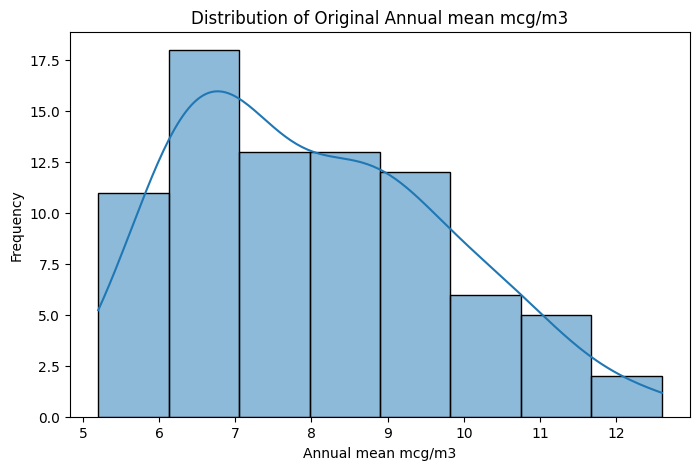

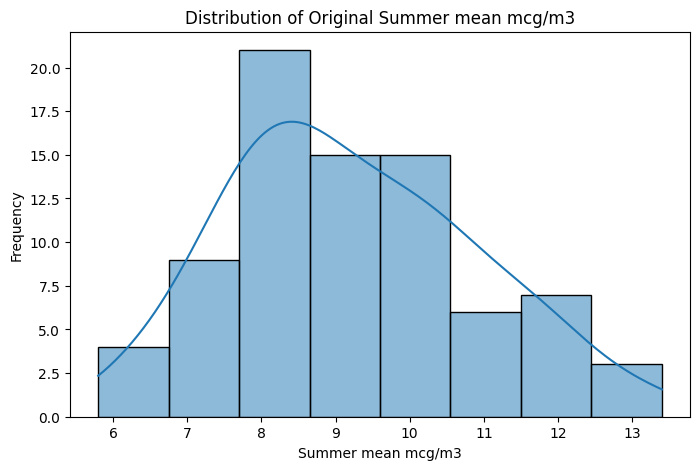

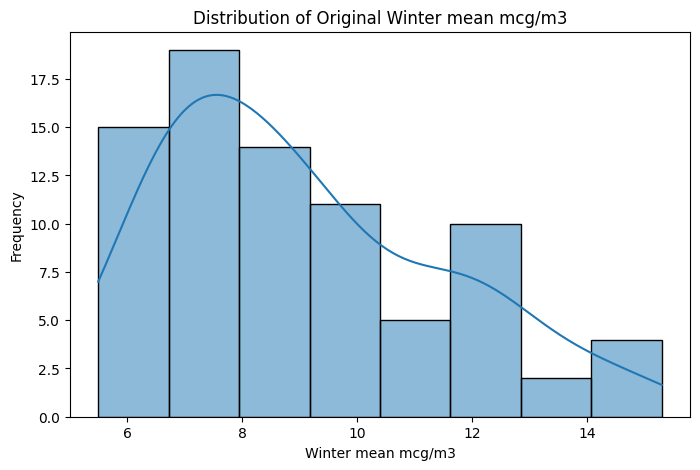

In [22]:
# Use histograms to visualize the distribution of the fine particles mean columns
# before seeing  how to handle the outliers
# Looking at the shape of the distribution helps us figure out if log transformation would be useful

# Plot the distribution of the annual mean fine particles values
plt.figure(figsize=(8, 5))
sns.histplot(fine_particles_df_cleaned['Annual mean mcg/m3'], kde=True)
plt.title('Distribution of Original Annual mean mcg/m3')
plt.xlabel('Annual mean mcg/m3')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of the summer mean fine particles values
plt.figure(figsize=(8, 5))
sns.histplot(fine_particles_df_cleaned['Summer mean mcg/m3'], kde=True)
plt.title('Distribution of Original Summer mean mcg/m3')
plt.xlabel('Summer mean mcg/m3')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of the winter mean fine particles values
plt.figure(figsize=(8, 5))
sns.histplot(fine_particles_df_cleaned['Winter mean mcg/m3'], kde=True)
plt.title('Distribution of Original Winter mean mcg/m3')
plt.xlabel('Winter mean mcg/m3')
plt.ylabel('Frequency')
plt.show()

In [23]:
# Since the histograms showed right-skewed distributions, apply some log transformation to the
# fine particles mean columns to reduce the skewness without removing any data
# Also print the skewness before and after to make sure that the transformation helped

# Apply the log transformation to the annual, summer, and winter mean fine particle columns
fine_particles_df_cleaned['Annual mean mcg/m3_log'] = np.log1p(fine_particles_df_cleaned['Annual mean mcg/m3'])
fine_particles_df_cleaned['Summer mean mcg/m3_log'] = np.log1p(fine_particles_df_cleaned['Summer mean mcg/m3'])
fine_particles_df_cleaned['Winter mean mcg/m3_log'] = np.log1p(fine_particles_df_cleaned['Winter mean mcg/m3'])

# Print the skewness before and after for the annual mean column
print(f'Original Skewness (Annual mean mcg/m3): {fine_particles_df_cleaned["Annual mean mcg/m3"].skew()}')
print(f'Log-transformed Skewness (Annual mean mcg/m3_log): {fine_particles_df_cleaned["Annual mean mcg/m3_log"].skew()}')

# Print the skewness before and after for the summer mean column
print(f'Original Skewness (Summer mean mcg/m3): {fine_particles_df_cleaned["Summer mean mcg/m3"].skew()}')
print(f'Log-transformed Skewness (Summer mean mcg/m3_log): {fine_particles_df_cleaned["Summer mean mcg/m3_log"].skew()}')

# Print the skewness before and after for the winter mean column
print(f'Original Skewness (Winter mean mcg/m3): {fine_particles_df_cleaned["Winter mean mcg/m3"].skew()}')
print(f'Log-transformed Skewness (Winter mean mcg/m3_log): {fine_particles_df_cleaned["Winter mean mcg/m3_log"].skew()}')

Original Skewness (Annual mean mcg/m3): 0.5218453372486896
Log-transformed Skewness (Annual mean mcg/m3_log): 0.2116040729918319
Original Skewness (Summer mean mcg/m3): 0.3501048379640109
Log-transformed Skewness (Summer mean mcg/m3_log): -0.002839089436137682
Original Skewness (Winter mean mcg/m3): 0.7150192812725452
Log-transformed Skewness (Winter mean mcg/m3_log): 0.34392875838795917


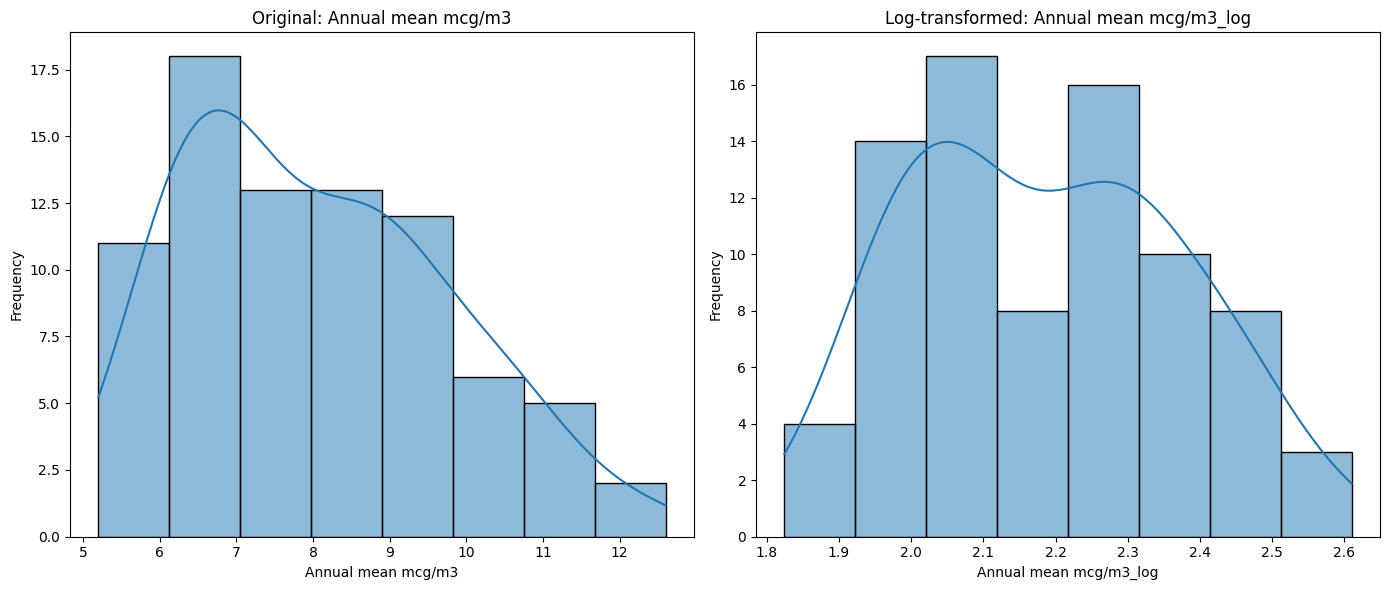

In [24]:
# Compare the original and log-transformed distributions for the annual mean fine particles column
# Plotting them side by side makes it easy to see how much the transformation changed the shape

# Set up a side by side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original annual mean distribution on the left
sns.histplot(fine_particles_df_cleaned['Annual mean mcg/m3'], kde=True, ax=axes[0])
axes[0].set_title('Original: Annual mean mcg/m3')
axes[0].set_xlabel('Annual mean mcg/m3')
axes[0].set_ylabel('Frequency')

# Plot the log-transformed annual mean distribution on the right
sns.histplot(fine_particles_df_cleaned['Annual mean mcg/m3_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed: Annual mean mcg/m3_log')
axes[1].set_xlabel('Annual mean mcg/m3_log')
axes[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

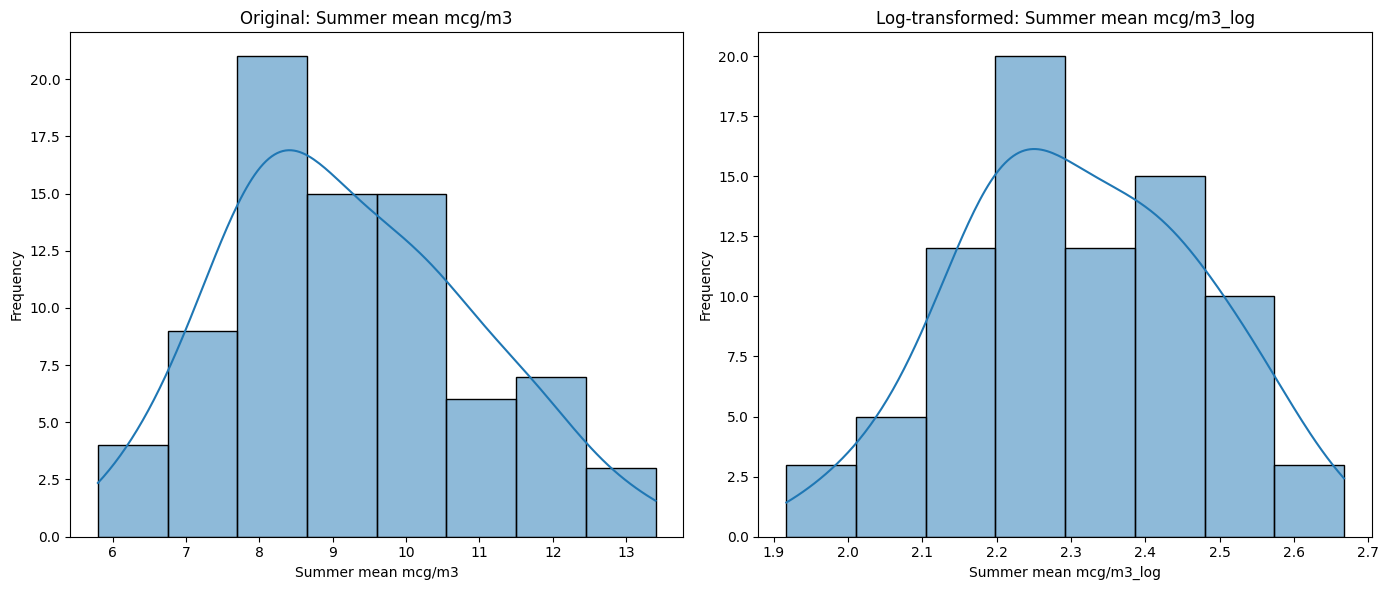

In [25]:
# Compare the original and log-transformed distributions for the summer mean fine particles column
# Plotting them side by side makes it easy to see how much the transformation changed the shape

# Set up a side by side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original summer mean distribution on the left
sns.histplot(fine_particles_df_cleaned['Summer mean mcg/m3'], kde=True, ax=axes[0])
axes[0].set_title('Original: Summer mean mcg/m3')
axes[0].set_xlabel('Summer mean mcg/m3')
axes[0].set_ylabel('Frequency')

# Plot the log-transformed summer mean distribution on the right
sns.histplot(fine_particles_df_cleaned['Summer mean mcg/m3_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed: Summer mean mcg/m3_log')
axes[1].set_xlabel('Summer mean mcg/m3_log')
axes[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

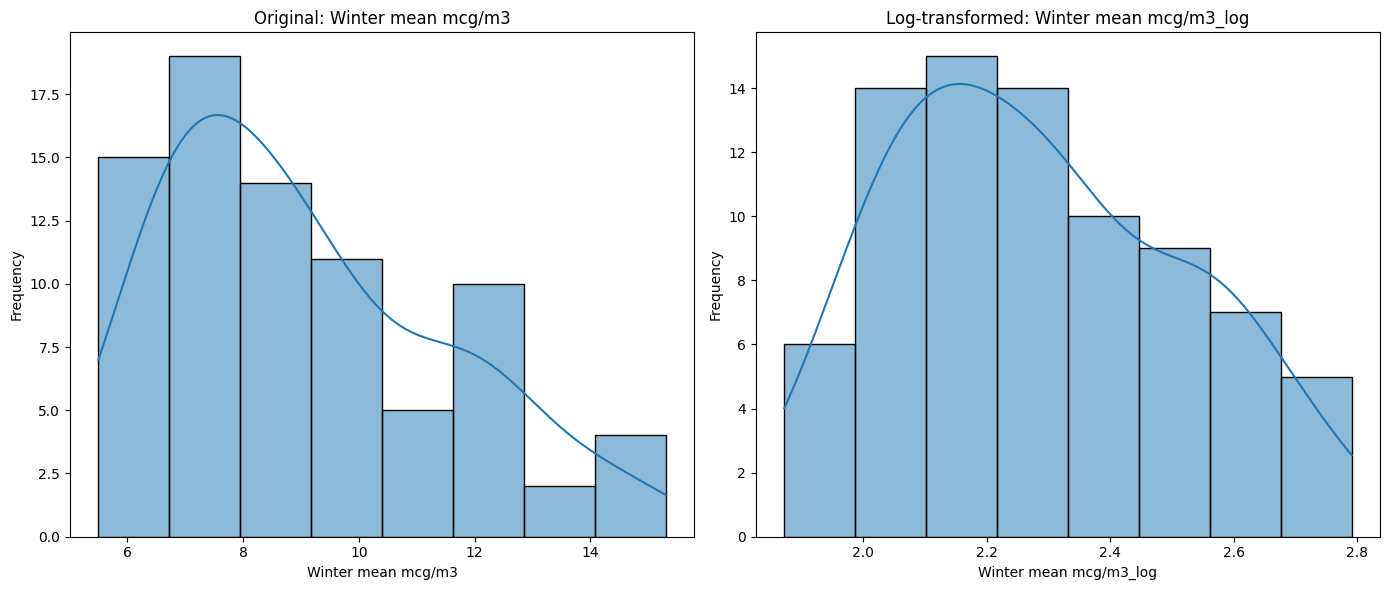

In [26]:
# Compare the original and log-transformed distributions for the winter mean fine particles column
# Plotting them side by side makes it easy to see how much the transformation changed the shape

# Set up a side by side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original winter mean distribution on the left
sns.histplot(fine_particles_df_cleaned['Winter mean mcg/m3'], kde=True, ax=axes[0])
axes[0].set_title('Original: Winter mean mcg/m3')
axes[0].set_xlabel('Winter mean mcg/m3')
axes[0].set_ylabel('Frequency')

# Plot the log-transformed winter mean distribution on the right
sns.histplot(fine_particles_df_cleaned['Winter mean mcg/m3_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed: Winter mean mcg/m3_log')
axes[1].set_xlabel('Winter mean mcg/m3_log')
axes[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Display the plot
plt.show()

In [27]:
# Check the updated fine particels dataframe after all the cleaning steps so far
# just ot make sure that everything looks right before going onto the next part

# Print some information about the fine particles dataframe including the column types and null counts
fine_particles_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TimePeriod              80 non-null     int64  
 1   BoroID                  80 non-null     int64  
 2   Borough                 80 non-null     str    
 3   Annual mean mcg/m3      80 non-null     float64
 4   Summer mean mcg/m3      80 non-null     float64
 5   Winter mean mcg/m3      80 non-null     float64
 6   Annual mean mcg/m3_log  80 non-null     float64
 7   Summer mean mcg/m3_log  80 non-null     float64
 8   Winter mean mcg/m3_log  80 non-null     float64
dtypes: float64(6), int64(2), str(1)
memory usage: 5.8 KB


In [28]:
# Convert the TimePeriod column in the fine particles dataset to a proper datetime format
# These values are stored as years so that we can use the %Y format to parse them properly

# Convert the TImePeriod column to datetime using the year format
fine_particles_df_cleaned['TimePeriod'] = pd.to_datetime(fine_particles_df_cleaned['TimePeriod'], format = '%Y', errors = 'coerce')

In [29]:
# Exploratory data analysis for the nitrogen dioxide dataset
# Take a quick look at the structure of the data, including the columns, shape, and data types,
# so that we know what we are working with before doing any cleaning

# Print the column names in the nitrogen dioxide dataset
print(f'Nitrogen Dioxide Columns: {nitrogen_dioxide_df.columns}\n')

# Print the number of rows and columns in the nitrogen dioxide dataset
print(f'Nitrogen Dioxide Shape: {nitrogen_dioxide_df.shape}\n')

# Print the first few rows of the nitrogen dioxide dataset to see what the data looks like
print(f'Nitrogen Dioxide DF Head:\n{nitrogen_dioxide_df.head()}\n')

# Print some information about the nitrogen dioxide dataset like column types and null counts
print('Nitrogen Dioxide DF Info:')
nitrogen_dioxide_df.info()

Nitrogen Dioxide Columns: Index(['TimePeriod', 'GeoTypeDesc', 'GeoID', 'GeoRank', 'BoroID', 'Borough',
       'Geography', 'Area', 'Annual mean ppb', 'Summer mean ppb',
       'Winter mean ppb'],
      dtype='str')

Nitrogen Dioxide Shape: (80, 11)

Nitrogen Dioxide DF Head:
   TimePeriod GeoTypeDesc  GeoID  GeoRank  BoroID        Borough  \
0        2024     Borough      3        1       3      Manhattan   
1        2024     Borough      2        1       2       Brooklyn   
2        2024     Borough      4        1       4         Queens   
3        2024     Borough      1        1       1          Bronx   
4        2024     Borough      5        1       5  Staten Island   

       Geography           Area  Annual mean ppb  Summer mean ppb  \
0      Manhattan      Manhattan             18.6             17.0   
1       Brooklyn       Brooklyn             14.6             11.4   
2         Queens         Queens             14.0             11.2   
3          Bronx          Bronx        

In [30]:
# Loop through each column in the nitrogen dioxide dataset and print the data type, unique values,
# and value counts to get a good understanding of what each column has

for col in nitrogen_dioxide_df.columns:
    # Print the data type of the column
    print(f'Column {col}: {nitrogen_dioxide_df[col].dtype}\n')

    # Print all the unique values in the column to check for anything unusual
    print(f'Nitrogen Dioxide DF Unique Values for {col}:{nitrogen_dioxide_df[col].unique()}\n')

    # Print how often each value appears in the column
    print(f'Nitrogen Dioxide DF Value Counts for {col}:{nitrogen_dioxide_df[col].value_counts()}\n')

Column TimePeriod: int64

Nitrogen Dioxide DF Unique Values for TimePeriod:[2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013 2012 2011
 2010 2009]

Nitrogen Dioxide DF Value Counts for TimePeriod:TimePeriod
2024    5
2023    5
2022    5
2021    5
2020    5
2019    5
2018    5
2017    5
2016    5
2015    5
2014    5
2013    5
2012    5
2011    5
2010    5
2009    5
Name: count, dtype: int64

Column GeoTypeDesc: str

Nitrogen Dioxide DF Unique Values for GeoTypeDesc:<StringArray>
['Borough']
Length: 1, dtype: str

Nitrogen Dioxide DF Value Counts for GeoTypeDesc:GeoTypeDesc
Borough    80
Name: count, dtype: int64

Column GeoID: int64

Nitrogen Dioxide DF Unique Values for GeoID:[3 2 4 1 5]

Nitrogen Dioxide DF Value Counts for GeoID:GeoID
3    16
2    16
4    16
1    16
5    16
Name: count, dtype: int64

Column GeoRank: int64

Nitrogen Dioxide DF Unique Values for GeoRank:[1]

Nitrogen Dioxide DF Value Counts for GeoRank:GeoRank
1    80
Name: count, dtype: int64

Column BoroID

In [31]:
# Check for duplicated rows in the nitrogen dioxide dataset to see which columns have
# redundant information and can be dropped
# Also make a dataframe of unique combinations to better see the structure

# Check how many rows are duplicated based on GeoID and BoroID
duplicate_ID = nitrogen_dioxide_df.duplicated(subset=['GeoID', 'BoroID']).sum()
print(f'Number of Duplicated Rows in Nitrogen Dioxide DF By GeoID and BoroID: {duplicate_ID}\n')

# Check how many rows are duplicated based on Borough, Geography, and Area
duplicated_geo_boro = nitrogen_dioxide_df.duplicated(subset=['Borough', 'Geography', 'Area']).sum()
print(f'Duplicated Rows in Nitrogen Dioxide DF By Borough, Geography, and Area:\n{duplicated_geo_boro}\n')

# Make a dataframe with only unique combinations to see how many distinct records there are
unique_nitrogen_combinations_df = nitrogen_dioxide_df.drop_duplicates(subset=['GeoID', 'BoroID', 'Borough', 'Geography', 'Area'])
print(f'Shape of Unique Combinations DF: {unique_nitrogen_combinations_df.shape}')
unique_nitrogen_combinations_df.head()

Number of Duplicated Rows in Nitrogen Dioxide DF By GeoID and BoroID: 75

Duplicated Rows in Nitrogen Dioxide DF By Borough, Geography, and Area:
75

Shape of Unique Combinations DF: (5, 11)


,TimePeriod,GeoTypeDesc,GeoID,GeoRank,BoroID,Borough,Geography,Area,Annual mean ppb,Summer mean ppb,Winter mean ppb
0,2024,Borough,3,1,3,Manhattan,Manhattan,Manhattan,18.6,17.0,22.5
1,2024,Borough,2,1,2,Brooklyn,Brooklyn,Brooklyn,14.6,11.4,20.4
2,2024,Borough,4,1,4,Queens,Queens,Queens,14.0,11.2,19.6
3,2024,Borough,1,1,1,Bronx,Bronx,Bronx,14.6,12.8,18.6
4,2024,Borough,5,1,5,Staten Island,Staten Island,Staten Island,11.9,9.0,16.2


In [32]:
# Drop columns from the nitrogen dioxide dataset that are redundant or not useful for the analysis
# Based on the duplicate checks from above, some columsn may have the same information as others
# and some only hav eone unique value which means they add no useful information

# Drop columns with redundant information based on the duplicate check results
nitrogen_dioxide_df_cleaned = nitrogen_dioxide_df.drop(columns=['GeoID', 'Geography', 'Area'])

# Drop columns with only one unique value since they will not be useful for the analysis
nitrogen_dioxide_df_cleaned = nitrogen_dioxide_df_cleaned.drop(columns=['GeoTypeDesc', 'GeoRank'])

# Print the updated shape and first few rows to confirm the columns were removed properly
print(f'Nitrogen Dioxide Cleaned Shape: {nitrogen_dioxide_df_cleaned.shape}\n')
print(f'Nitrogen Dioxide Cleaned Head:\n{nitrogen_dioxide_df_cleaned.head()}\n')

# Print some info of the cleaned dataframe
print('Nitrogen Dioxide Info:')
nitrogen_dioxide_df_cleaned.info() 

Nitrogen Dioxide Cleaned Shape: (80, 6)

Nitrogen Dioxide Cleaned Head:
   TimePeriod  BoroID        Borough  Annual mean ppb  Summer mean ppb  \
0        2024       3      Manhattan             18.6             17.0   
1        2024       2       Brooklyn             14.6             11.4   
2        2024       4         Queens             14.0             11.2   
3        2024       1          Bronx             14.6             12.8   
4        2024       5  Staten Island             11.9              9.0   

   Winter mean ppb  
0             22.5  
1             20.4  
2             19.6  
3             18.6  
4             16.2  

Nitrogen Dioxide Info:
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TimePeriod       80 non-null     int64  
 1   BoroID           80 non-null     int64  
 2   Borough          80 non-null     str    
 3   Annual 

In [33]:
# Since there are no null values in the nitrogen dioxide dataset, we went ahead and check
# for outliers in the annual mean column using the IQR function we defined earlier

# Run the IQR function on the annual mean column to find the outliers
nitrogen_dioxide_annual_outliers = find_iqr_outliers(nitrogen_dioxide_df_cleaned, 'Annual mean ppb')

# Print the number of outliers found in the annual mean column
print(f'Number of Outliers in Nitrogen Dioxide Annual Column: {len(nitrogen_dioxide_annual_outliers)}\n')

# Print the shape of the outliers dataframe
print(f'Nitrogen Dioxide Annual Outliers Shape: {nitrogen_dioxide_annual_outliers.shape}\n')

# Print the first few outlier rows to see what they look like
print(f'Nitrogen Dioxide Annual Outliers Head:\n{nitrogen_dioxide_annual_outliers.head()}\n')

# Print some summary stats for the outliers in the annual mean column
print(f'Nitrogen Dioxide Annual Outliers Description:\n{nitrogen_dioxide_annual_outliers["Annual mean ppb"].describe()}\n')

Number of Outliers in Nitrogen Dioxide Annual Column: 3

Nitrogen Dioxide Annual Outliers Shape: (3, 6)

Nitrogen Dioxide Annual Outliers Head:
    TimePeriod  BoroID    Borough  Annual mean ppb  Summer mean ppb  \
65        2011       3  Manhattan             31.0             27.7   
70        2010       3  Manhattan             30.6             28.5   
75        2009       3  Manhattan             33.9             30.9   

    Winter mean ppb  
65             35.4  
70             32.2  
75             38.4  

Nitrogen Dioxide Annual Outliers Description:
count     3.000000
mean     31.833333
std       1.800926
min      30.600000
25%      30.800000
50%      31.000000
75%      32.450000
max      33.900000
Name: Annual mean ppb, dtype: float64



In [34]:
# Since there are no null values in the nitrogen dioxide dataset, we can also check
# for outliers in the summer mean column using the IQR function

# Run the IQR function on the summer mean column to find outliers
nitrogen_dioxide_summer_outliers = find_iqr_outliers(nitrogen_dioxide_df_cleaned, 'Summer mean ppb')

# Print the number of outliers found in the summer mean column
print(f'Number of Outliers in Nitrogen Dioxide Summer Column: {len(nitrogen_dioxide_summer_outliers)}\n')

# Print the shape of the outliers dataframe
print(f'Nitrogen Dioxide Summer Outliers Shape: {nitrogen_dioxide_summer_outliers.shape}\n')

# Print the first few outlier rows to see what they look like
print(f'Nitrogen Dioxide Summer Outliers Head:\n{nitrogen_dioxide_summer_outliers.head()}\n')

# Print some summary stats for the outliers in the summer mean column
print(f'Nitrogen Dioxide Summer Outliers Description:\n{nitrogen_dioxide_summer_outliers["Summer mean ppb"].describe()}\n')

Number of Outliers in Nitrogen Dioxide Summer Column: 4

Nitrogen Dioxide Summer Outliers Shape: (4, 6)

Nitrogen Dioxide Summer Outliers Head:
    TimePeriod  BoroID    Borough  Annual mean ppb  Summer mean ppb  \
60        2012       3  Manhattan             28.7             25.8   
65        2011       3  Manhattan             31.0             27.7   
70        2010       3  Manhattan             30.6             28.5   
75        2009       3  Manhattan             33.9             30.9   

    Winter mean ppb  
60             30.2  
65             35.4  
70             32.2  
75             38.4  

Nitrogen Dioxide Summer Outliers Description:
count     4.000000
mean     28.225000
std       2.112463
min      25.800000
25%      27.225000
50%      28.100000
75%      29.100000
max      30.900000
Name: Summer mean ppb, dtype: float64



In [35]:
# Since there are no null values in the nitrogen dioxide dataset, we go ahead and check
# for outliers in the winter mean column using the IQR function

# Run the IQR function on the winter mean column to find the outliers
nitrogen_dioxide_winter_outliers = find_iqr_outliers(nitrogen_dioxide_df_cleaned, 'Winter mean ppb')

# Print the number of outliers found in the winter mean column
print(f'Number of Outliers in Nitrogen Dioxide Winter Column: {len(nitrogen_dioxide_winter_outliers)}\n')

# Print the shape of the outliers dataframe
print(f'Nitrogen Dioxide Winter Outliers Shape: {nitrogen_dioxide_winter_outliers.shape}\n')

# Print the first few outlier rows to see what they look like
print(f'Nitrogen Dioxide Winter Outliers Head:\n{nitrogen_dioxide_winter_outliers.head()}\n')

# Print some summary stats for the outliers in the winter mean column
print(f'Nitrogen Dioxide Winter Outliers Description:\n{nitrogen_dioxide_winter_outliers["Winter mean ppb"].describe()}\n')

Number of Outliers in Nitrogen Dioxide Winter Column: 1

Nitrogen Dioxide Winter Outliers Shape: (1, 6)

Nitrogen Dioxide Winter Outliers Head:
    TimePeriod  BoroID    Borough  Annual mean ppb  Summer mean ppb  \
75        2009       3  Manhattan             33.9             30.9   

    Winter mean ppb  
75             38.4  

Nitrogen Dioxide Winter Outliers Description:
count     1.0
mean     38.4
std       NaN
min      38.4
25%      38.4
50%      38.4
75%      38.4
max      38.4
Name: Winter mean ppb, dtype: float64



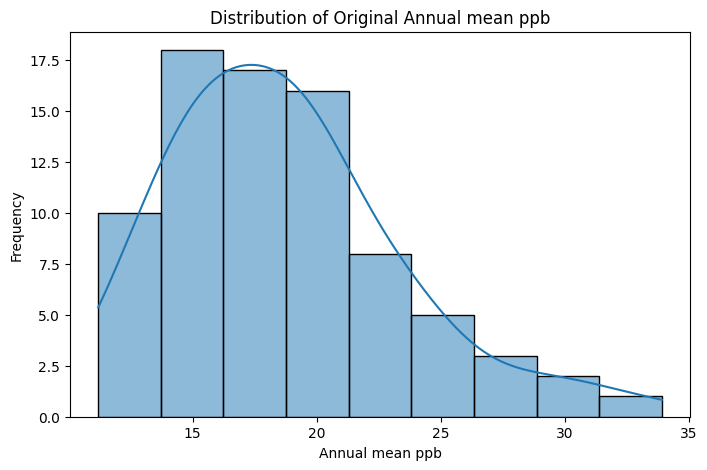

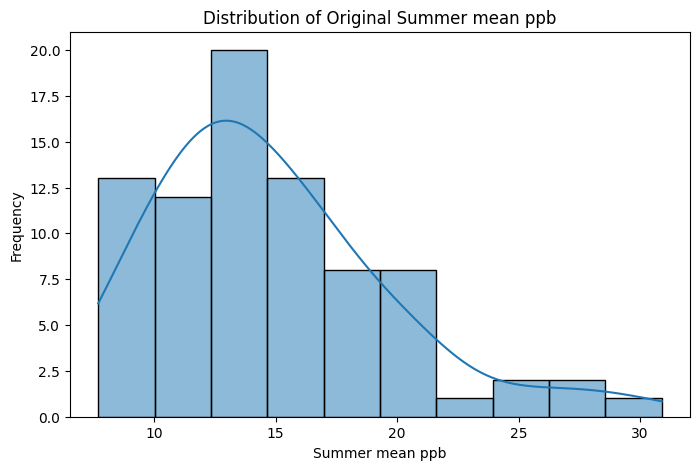

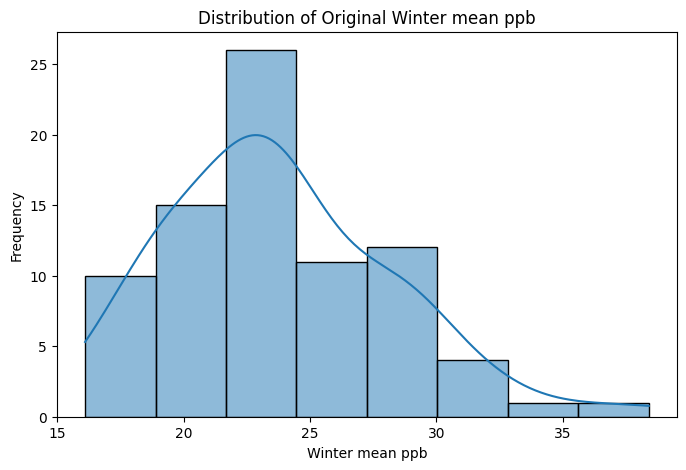

In [36]:
# Use histograms to visualize the distribution of the nitrogen dioxide mean columns
# before deciding how to handle the outliers without removing them from the dataset
# Looking at the shape helps us understand whether log transformation would be a good approach

# Use histograms to visualize the distribution of nitrogen dioxide mean columns
# before seeing how to handle the outliers without removing them from the dataset
# Looking at the shape helps understand whether log transofmration would be a good strategy

# Plot the distribution of the annual mean NO2 values
plt.figure(figsize=(8, 5))
sns.histplot(nitrogen_dioxide_df_cleaned['Annual mean ppb'], kde=True)
plt.title('Distribution of Original Annual mean ppb')
plt.xlabel('Annual mean ppb')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of the summer mean NO2 values
plt.figure(figsize=(8, 5))
sns.histplot(nitrogen_dioxide_df_cleaned['Summer mean ppb'], kde=True)
plt.title('Distribution of Original Summer mean ppb')
plt.xlabel('Summer mean ppb')
plt.ylabel('Frequency')
plt.show()

# Plot the distribution of the winter mean NO2 values
plt.figure(figsize=(8, 5))
sns.histplot(nitrogen_dioxide_df_cleaned['Winter mean ppb'], kde=True)
plt.title('Distribution of Original Winter mean ppb')
plt.xlabel('Winter mean ppb')
plt.ylabel('Frequency')
plt.show()

In [37]:
# Since the histograms showed right-skewed distributions, use log transformations to the
# nitrogen dioxide mean columns to handle the skewness without removing any important data
# Also print the skewness before and after to make sure the the transformation actually helped

# Use log transformation to the annual, summer, and winter mean NO2 columns
nitrogen_dioxide_df_cleaned['Annual mean ppb_log'] = np.log1p(nitrogen_dioxide_df_cleaned['Annual mean ppb'])
nitrogen_dioxide_df_cleaned['Summer mean ppb_log'] = np.log1p(nitrogen_dioxide_df_cleaned['Summer mean ppb'])
nitrogen_dioxide_df_cleaned['Winter mean ppb_log'] = np.log1p(nitrogen_dioxide_df_cleaned['Winter mean ppb'])

# Print the skewness before and after for the annual mean column
print(f'Original Skewness (Annual mean ppb): {nitrogen_dioxide_df_cleaned["Annual mean ppb"].skew()}')
print(f'Log-transformed Skewness (Annual mean ppb_log): {nitrogen_dioxide_df_cleaned["Annual mean ppb_log"].skew()}')

# Print the skewness before and after for the summer mean column
print(f'Original Skewness (Summer mean ppb): {nitrogen_dioxide_df_cleaned["Summer mean ppb"].skew()}')
print(f'Log-transformed Skewness (Summer mean ppb_log): {nitrogen_dioxide_df_cleaned["Summer mean ppb_log"].skew()}')

# Print the skewness before and after for the winter mean column
print(f'Original Skewness (Winter mean ppb): {nitrogen_dioxide_df_cleaned["Winter mean ppb"].skew()}')
print(f'Log-transformed Skewness (Winter mean ppb_log): {nitrogen_dioxide_df_cleaned["Winter mean ppb_log"].skew()}')

Original Skewness (Annual mean ppb): 0.9327920598567639
Log-transformed Skewness (Annual mean ppb_log): 0.30859276466047225
Original Skewness (Summer mean ppb): 1.0854982348538893
Log-transformed Skewness (Summer mean ppb_log): 0.2948694469554349
Original Skewness (Winter mean ppb): 0.6949057173340899
Log-transformed Skewness (Winter mean ppb_log): 0.2108111074777692


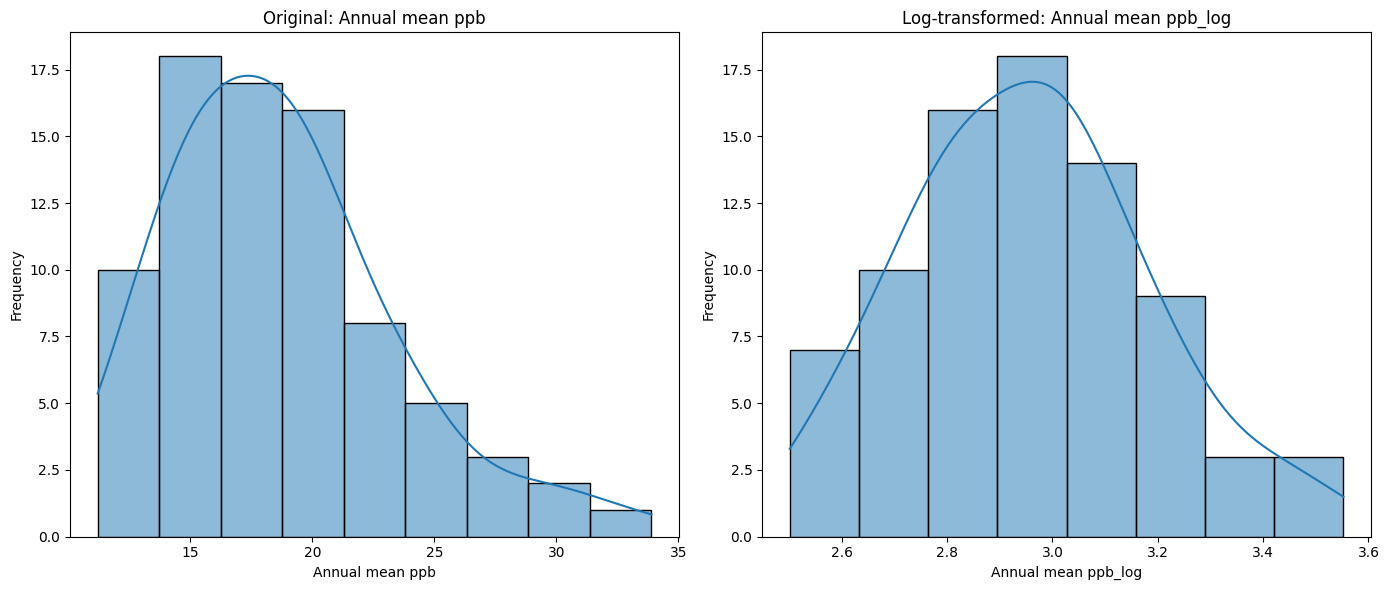

In [38]:
# Compare the original and log-transformed distributions for the annual mean NO2 column
# Plotting them side by side makes it easy to see how much the transformation changed the shape

# Set up a side by side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original annual mean NO2 distribution on the left
sns.histplot(nitrogen_dioxide_df_cleaned['Annual mean ppb'], kde=True, ax=axes[0])
axes[0].set_title('Original: Annual mean ppb')
axes[0].set_xlabel('Annual mean ppb')
axes[0].set_ylabel('Frequency')

# Plot the log-transformed annual mean NO2 distribution on the right
sns.histplot(nitrogen_dioxide_df_cleaned['Annual mean ppb_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed: Annual mean ppb_log')
axes[1].set_xlabel('Annual mean ppb_log')
axes[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

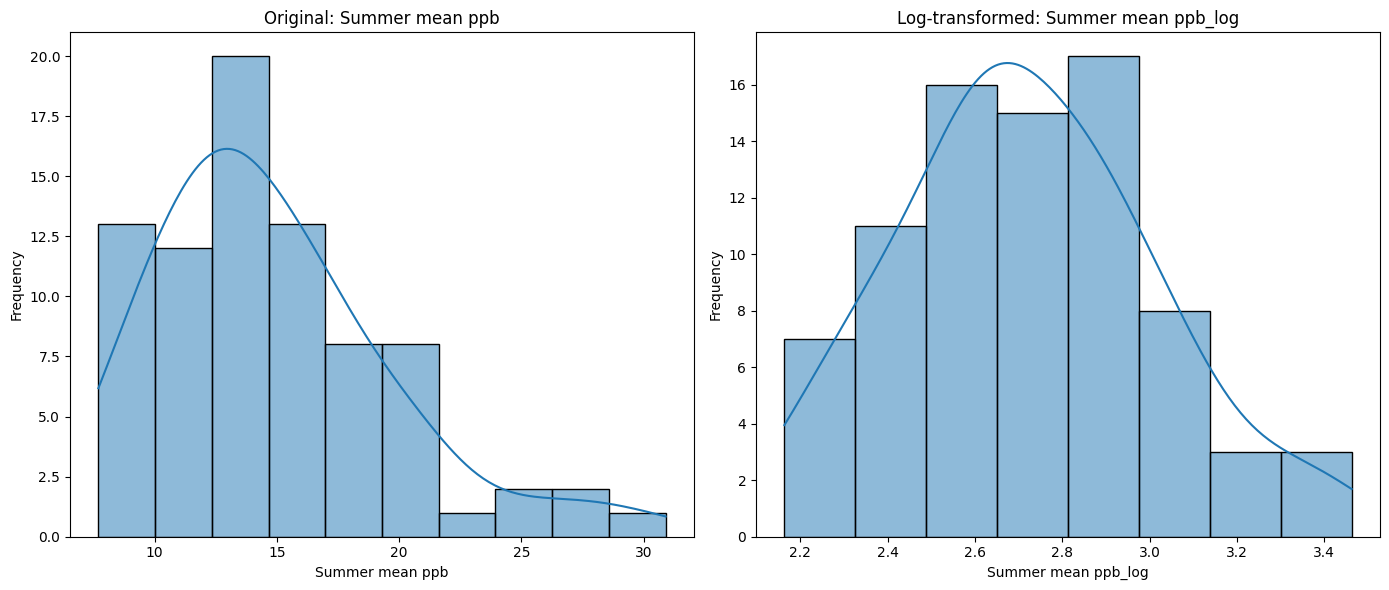

In [ ]:
# Compare the original and log-transformed distributions for the summer mean NO2 column
# Plotting them side by side makes it easy to see how much the transformation changed the shape

# Set up a side by side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original summer mean NO2 distribution on the left
sns.histplot(nitrogen_dioxide_df_cleaned['Summer mean ppb'], kde=True, ax=axes[0])
axes[0].set_title('Original: Summer mean ppb')
axes[0].set_xlabel('Summer mean ppb')
axes[0].set_ylabel('Frequency')

# Plot the log-transformed summer mean NO2 distribution on the right
sns.histplot(nitrogen_dioxide_df_cleaned['Summer mean ppb_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed: Summer mean ppb_log')
axes[1].set_xlabel('Summer mean ppb_log')
axes[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

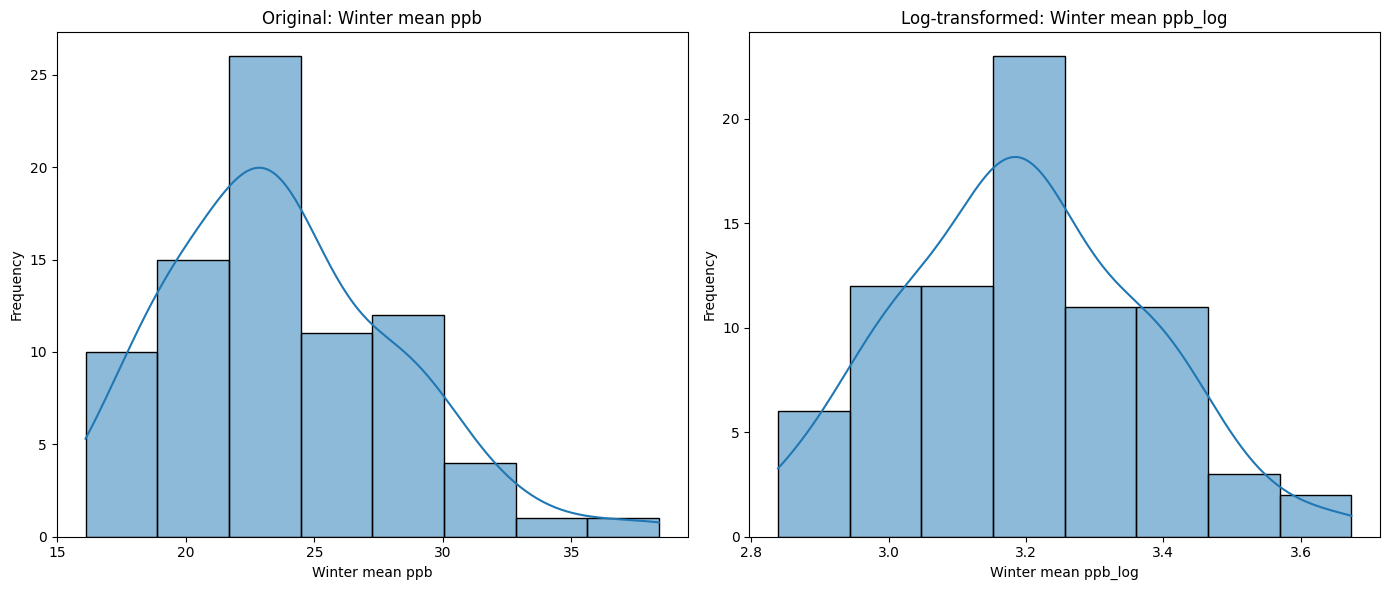

In [40]:
# Compare the original and log-transformed distributions for the winter mean NO2 column
# Plotting them side by side makes it easy to see how much the transformation changed the shape

# Set up a side by side figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the original winter mean NO2 distribution on the left
sns.histplot(nitrogen_dioxide_df_cleaned['Winter mean ppb'], kde=True, ax=axes[0])
axes[0].set_title('Original: Winter mean ppb')
axes[0].set_xlabel('Winter mean ppb')
axes[0].set_ylabel('Frequency')

# Plot the log-transformed winter mean NO2 distribution on the right
sns.histplot(nitrogen_dioxide_df_cleaned['Winter mean ppb_log'], kde=True, ax=axes[1])
axes[1].set_title('Log-transformed: Winter mean ppb_log')
axes[1].set_xlabel('Winter mean ppb_log')
axes[1].set_ylabel('Frequency')

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [41]:
# Check the updated nitrogen dioxide dataframe after all the cleaning steps so far
# to make sure that everything looks right before moving on to the next part

# Print information about the nitrogen dioxide dataframe including the column types and null counts
nitrogen_dioxide_df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TimePeriod           80 non-null     int64  
 1   BoroID               80 non-null     int64  
 2   Borough              80 non-null     str    
 3   Annual mean ppb      80 non-null     float64
 4   Summer mean ppb      80 non-null     float64
 5   Winter mean ppb      80 non-null     float64
 6   Annual mean ppb_log  80 non-null     float64
 7   Summer mean ppb_log  80 non-null     float64
 8   Winter mean ppb_log  80 non-null     float64
dtypes: float64(6), int64(2), str(1)
memory usage: 5.8 KB


In [42]:
# Convert the TimePeriod column in the nitrogen dioxide dataset to a proper datetime format
# Values are stored as years so we use the %Y to parse them properly

# Convert the TimePeriod column to datetime using the year format
nitrogen_dioxide_df_cleaned['TimePeriod'] = pd.to_datetime(nitrogen_dioxide_df_cleaned['TimePeriod'], format = '%Y')

In [43]:
# One-hot encoding to the borough columns across all three datasets so they can be
# used as numeric features in the model later on
# Fit the encoder on all boroughs combined so the categories are consistent across datasets,
# and then transform each dataset separately and merge the encoded columns back in

# Combine all of the borough values from the three datasets to fit the encoder on all possible categories
all_boroughs = pd.concat([traffic_df_cleaned['Boro'].str.title().str.strip(), fine_particles_df_cleaned['Borough'].str.title().str.strip(), nitrogen_dioxide_df_cleaned['Borough'].str.title().str.strip()])

# Print the value counts to make sure all five boroughs are represented
print(f'All Boroughs Values:\n{all_boroughs.value_counts()}\n')

# Reshape the borough values into the format expected by the encoder
all_boroughs_reshaped = all_boroughs.values.reshape(-1, 1)

# Make the encoder dropping the first category to avoid multicollinearity
encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False, drop = 'first')

# Reshape the borough column from the traffic dataset for encoding
encoder.fit(all_boroughs_reshaped)
print("Learned categories:", encoder.categories_)

# Reshape the borough column from the traffic dataset for encoding
traffic_boroughs_reshaped = traffic_df_cleaned['Boro'].values.reshape(-1, 1)

# Apply the encoder to the traffic borough column
traffic_encoded = encoder.transform(traffic_boroughs_reshaped)

# Reshape the borough column from the fine particles dataset for encoding
fine_particles_boroughs_reshaped = fine_particles_df_cleaned['Borough'].values.reshape(-1, 1)

# Apply the encoder to the fine particles borough column
fine_particles_encoded = encoder.transform(fine_particles_boroughs_reshaped)

# Reshape the borough column from the nitrogen dioxide dataset for encoding
nitrogen_dioxide_boroughs_reshaped = nitrogen_dioxide_df_cleaned['Borough'].values.reshape(-1, 1)

# Apply the encoder to the nitrogen dioxide borough column
nitrogen_dioxide_encoded = encoder.transform(nitrogen_dioxide_boroughs_reshaped)

# Get the encoded column names for the traffic dataset and merge them back in
traffic_encoded_borough_names = encoder.get_feature_names_out(['Boro'])
traffic_encode_df = pd.DataFrame(traffic_encoded,
                               columns = traffic_encoded_borough_names,
                               index=traffic_df_cleaned.index)
traffic_df_cleaned = pd.concat([traffic_df_cleaned, traffic_encode_df], axis = 1)

# Drop the original Boro column now that we have the encoded version
traffic_df_cleaned = traffic_df_cleaned.drop('Boro', axis = 1)

# Get the encoded column names for the pollutant datasets and merge them into the fine particles dataframe
pollutants_borough_names = encoder.get_feature_names_out(['Borough'])
fine_particles_encode_df = pd.DataFrame(fine_particles_encoded,
                                      columns = pollutants_borough_names,
                                      index = fine_particles_df_cleaned.index)
fine_particles_df_cleaned = pd.concat([fine_particles_df_cleaned, fine_particles_encode_df], axis = 1)

# Drop the original Borough column from the fine particles dataset
fine_particles_df_cleaned = fine_particles_df_cleaned.drop('Borough', axis = 1)

# Merge the encoded borough columsn into the nitrogen dioxide dataframe
nitrogen_dioxide_encode_df = pd.DataFrame(nitrogen_dioxide_encoded,
                                         columns = pollutants_borough_names,
                                         index = nitrogen_dioxide_df_cleaned.index)
nitrogen_dioxide_df_cleaned = pd.concat([nitrogen_dioxide_df_cleaned, nitrogen_dioxide_encode_df], axis = 1)

# Drop the original Borough column from the nitrogen dioxide dataset
nitrogen_dioxide_df_cleaned = nitrogen_dioxide_df_cleaned.drop('Borough', axis = 1)

All Boroughs Values:
Queens           547122
Brooklyn         524508
Manhattan        338279
Bronx            293703
Staten Island    119401
Name: count, dtype: int64

Learned categories: [array(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'],
      dtype=object)]


In [44]:
# Do one last check on all three cleaned datasets to make sure everything looks good before saving them to CSV files

# Print the final information for the traffic dataset
print('Final Traffic DF Info:')
traffic_df_cleaned.info()
print('\n')

# Print the final information for the fine particles dataset
print('Final Fine Particles DF Info:')
fine_particles_df_cleaned.info()
print('\n')

# Print the final information for the nitrogen dioxide dataset
print('Final Nitrogen Dioxide DF Info:')
nitrogen_dioxide_df_cleaned.info()

Final Traffic DF Info:
<class 'pandas.DataFrame'>
Index: 1822853 entries, 0 to 1875153
Data columns (total 11 columns):
 #   Column              Dtype         
---  ------              -----         
 0   RequestID           int64         
 1   Vol                 int64         
 2   SegmentID           int64         
 3   WktGeom             str           
 4   Direction           str           
 5   DateTime            datetime64[us]
 6   Vol_log             float64       
 7   Boro_Brooklyn       float64       
 8   Boro_Manhattan      float64       
 9   Boro_Queens         float64       
 10  Boro_Staten Island  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory usage: 166.9 MB


Final Fine Particles DF Info:
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   TimePeriod              80 non-n

In [45]:
# Sort each cleaned dataset by date in descending order and save them as CSV files
# so that they are ready to be loaded into the analysis and modeling part of our project

# Sort the traffic dataset by DateTime and save it to the processed data folder
traffic_df_cleaned = traffic_df_cleaned.sort_values(by = 'DateTime', ascending = False).reset_index(drop = True)
traffic_df_cleaned.to_csv(r'processed_data\cleaned_traffic_data.csv', index = False)

# Sort the fine particles dataset by TimePeriod and save it to the processed data folder
fine_particles_df_cleaned = fine_particles_df_cleaned.sort_values(by = 'TimePeriod', ascending = False).reset_index(drop = True)
fine_particles_df_cleaned.to_csv(r'processed_data\cleaned_fine_particles_data.csv', index = False)

# Sort the nitrogen dioxide dataset by TimePeriod and save it to the processed data folder
nitrogen_dioxide_df_cleaned = nitrogen_dioxide_df_cleaned.sort_values(by = 'TimePeriod', ascending = False).reset_index(drop=True)
nitrogen_dioxide_df_cleaned.to_csv(r'processed_data\cleaned_nitrogen_dioxide_data.csv', index = False)